In [ ]:
from pathlib import Path
import shutil
import zipfile
import sys
from datetime import datetime, timezone

OUTPUT_DIR = Path('./output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COLAB_PROJECT_DIR = Path('/content/drive/MyDrive/bureaucratic-workflow-analyzer')
COLAB_SOURCE_OUTPUT_DIR = COLAB_PROJECT_DIR / 'output'

REQUIRED_INPUT_FILES = [
    'sim_trace_table.csv',
    'sim_episode_summary.csv',
]
CASE_FEATURE_OPTIONS = ['case_step_features.parquet', 'case_step_features.csv']

STEP7_OUTPUT_FILES = [
    'sim_validation_metrics_by_run.csv',
    'sim_validation_report.csv',
    'sim_validation_chart.png',
]

IS_COLAB = False
try:
    from google.colab import files  
    from IPython import get_ipython
    from google.colab import drive  
    IS_COLAB = True
except Exception:
    files = None
    get_ipython = None
    drive = None


def _ensure_colab_project_dir() -> Path:
    if not IS_COLAB:
        return COLAB_PROJECT_DIR

    if COLAB_PROJECT_DIR.exists():
        return COLAB_PROJECT_DIR

    if drive is not None and not Path('/content/drive').exists():
        try:
            drive.mount('/content/drive')
        except Exception:
            pass

    if not COLAB_PROJECT_DIR.exists():
        raise FileNotFoundError(
            f'Project path not found: {COLAB_PROJECT_DIR}. '
            'Update COLAB_PROJECT_DIR in Cell 1 to your Drive project folder.'
        )

    return COLAB_PROJECT_DIR


def _add_project_to_syspath() -> None:
    project_dir = _ensure_colab_project_dir()
    if str(project_dir) not in sys.path:
        sys.path.insert(0, str(project_dir))
    print(f'Python import path enabled: {project_dir}')


def _ensure_colab_source_dir() -> Path:
    _ensure_colab_project_dir()
    if not COLAB_SOURCE_OUTPUT_DIR.exists():
        raise FileNotFoundError(
            f'Output folder not found: {COLAB_SOURCE_OUTPUT_DIR}. '
            'Expected your files under <project>/output.'
        )
    return COLAB_SOURCE_OUTPUT_DIR


def copy_required_inputs_from_hardcoded_path() -> None:
    if not IS_COLAB:
        print('Not running in Colab; skipping hardcoded input copy.')
        return

    src_dir = _ensure_colab_source_dir()
    copied = []

    chosen_case_file = None
    for candidate in CASE_FEATURE_OPTIONS:
        src = src_dir / candidate
        if src.exists():
            shutil.copy2(src, OUTPUT_DIR / candidate)
            chosen_case_file = candidate
            copied.append(candidate)
            break

    if chosen_case_file is None:
        raise FileNotFoundError(
            f'None of {CASE_FEATURE_OPTIONS} found in {src_dir}. '
            'At least one case features file is required.'
        )

    required_missing = []
    for name in REQUIRED_INPUT_FILES:
        src = src_dir / name
        if src.exists():
            shutil.copy2(src, OUTPUT_DIR / name)
            copied.append(name)
        else:
            if name == 'sim_episode_summary.csv':
                continue
            required_missing.append(name)

    if required_missing:
        raise FileNotFoundError(
            f'Missing required input files in {src_dir}: {required_missing}'
        )

    print('Copied to ./output from hardcoded path:', copied)


_STEP7_BUNDLE_DOWNLOADED = False


def sync_step7_outputs_to_source_dir() -> None:
    if not IS_COLAB:
        return

    src_dir = _ensure_colab_source_dir()
    src_dir.mkdir(parents=True, exist_ok=True)
    synced = []
    for name in STEP7_OUTPUT_FILES:
        path = OUTPUT_DIR / name
        if path.exists():
            shutil.copy2(path, src_dir / name)
            synced.append(name)

    if synced:
        print(f'Synced outputs to {src_dir}:', synced)


def download_step7_outputs_bundle() -> None:
    global _STEP7_BUNDLE_DOWNLOADED
    if not IS_COLAB:
        print('Not running in Colab; skipping download bundle.')
        return

    existing = [OUTPUT_DIR / name for name in STEP7_OUTPUT_FILES if (OUTPUT_DIR / name).exists()]
    if not existing:
        print('No Step 7 output files found yet in ./output.')
        return

    stamp = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')
    bundle_name = f'step7_outputs_{stamp}.zip'
    bundle_path = Path('./') / bundle_name

    with zipfile.ZipFile(bundle_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
        for path in existing:
            zf.write(path, arcname=str(path))

    sync_step7_outputs_to_source_dir()
    files.download(str(bundle_path))
    _STEP7_BUNDLE_DOWNLOADED = True
    print(f'Download started for: {bundle_name}')


def _auto_finish_after_cells(*_) -> None:
    if _STEP7_BUNDLE_DOWNLOADED or not IS_COLAB:
        return
    ready = all((OUTPUT_DIR / name).exists() for name in STEP7_OUTPUT_FILES)
    if ready:
        download_step7_outputs_bundle()
        ip = get_ipython() if get_ipython else None
        if ip is not None:
            try:
                ip.events.unregister('post_run_cell', _auto_finish_after_cells)
            except Exception:
                pass


if IS_COLAB:
    _add_project_to_syspath()
    copy_required_inputs_from_hardcoded_path()
    ip = get_ipython() if get_ipython else None
    if ip is not None:
        try:
            ip.events.register('post_run_cell', _auto_finish_after_cells)
            print('Registered auto-finish hook (sync + download bundle when Step 7 outputs are ready).')
        except Exception:
            print('Could not register auto hook; call download_step7_outputs_bundle() manually at the end.')
else:
    print('Colab hardcoded-path bootstrap loaded (local runtime detected).')

Colab hardcoded-path bootstrap loaded (local runtime detected).


# Step 7 — Simulator Validation

This notebook runs Step 7 validation flow:
1. Load real and simulated outputs.
2. Compute the 5 Step 7 validation metrics by run.
3. Save summary artifacts for reporting and iteration.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUTPUT_DIR = Path('./output')

REAL_FEATURES_PARQUET = OUTPUT_DIR / 'case_step_features.parquet'
REAL_FEATURES_CSV = OUTPUT_DIR / 'case_step_features.csv'

SIMPY_TRACE_PATH = OUTPUT_DIR / 'sim_trace_table.csv'
SIMPY_EPISODE_PATH = OUTPUT_DIR / 'sim_episode_summary.csv'

METRICS_BY_RUN_PATH = OUTPUT_DIR / 'sim_validation_metrics_by_run.csv'
REPORT_PATH = OUTPUT_DIR / 'sim_validation_report.csv'
CHART_PATH = OUTPUT_DIR / 'sim_validation_chart.png'

print('Output dir:', OUTPUT_DIR.resolve())

Output dir: /home/praharsha/Desktop/bueracratic-workflow-analyzer/output


In [3]:
if REAL_FEATURES_PARQUET.exists():
    real_df = pd.read_parquet(REAL_FEATURES_PARQUET)
    real_loaded_from = REAL_FEATURES_PARQUET
elif REAL_FEATURES_CSV.exists():
    real_df = pd.read_csv(REAL_FEATURES_CSV)
    real_loaded_from = REAL_FEATURES_CSV
else:
    raise FileNotFoundError('Missing real features file in ./output')

if not SIMPY_TRACE_PATH.exists():
    raise FileNotFoundError(f'Missing SimPy trace file: {SIMPY_TRACE_PATH}')

sim_trace_df = pd.read_csv(SIMPY_TRACE_PATH)
sim_episode_df = pd.read_csv(SIMPY_EPISODE_PATH) if SIMPY_EPISODE_PATH.exists() else None

if 'timestamp' in real_df.columns:
    real_df['timestamp'] = pd.to_datetime(real_df['timestamp'], utc=True, errors='coerce')
if 'timestamp' in sim_trace_df.columns:
    sim_trace_df['timestamp'] = pd.to_datetime(sim_trace_df['timestamp'], utc=True, errors='coerce')

if 'run_id' not in sim_trace_df.columns:
    sim_trace_df['run_id'] = 1
sim_trace_df['run_id'] = pd.to_numeric(sim_trace_df['run_id'], errors='coerce').fillna(1).astype(int)

if sim_episode_df is not None:
    if 'run_id' not in sim_episode_df.columns:
        sim_episode_df['run_id'] = 1
    sim_episode_df['run_id'] = pd.to_numeric(sim_episode_df['run_id'], errors='coerce').fillna(1).astype(int)

print(f'Real rows : {len(real_df):,} (from {real_loaded_from.name})')
print(f'Sim rows  : {len(sim_trace_df):,}')
print(f'Sim runs  : {sim_trace_df["run_id"].nunique():,}')
print(f'Episode rows: {0 if sim_episode_df is None else len(sim_episode_df):,}')

/tmp/ipykernel_38608/170568488.py:13: DtypeWarning: Columns (0: sim_actor) have mixed types. Specify dtype option on import or set low_memory=False.
  sim_trace_df = pd.read_csv(SIMPY_TRACE_PATH)


Real rows : 262,628 (from case_step_features.parquet)
Sim rows  : 425,490
Sim runs  : 20
Episode rows: 12,000


## 7.1 Direct validation

This section validates current simulation outputs directly against real data.

In [5]:
def build_real_case_summary(real_features: pd.DataFrame) -> pd.DataFrame:
    base = real_features.sort_values(['municipality', 'case_id', 'step_index'])
    case_steps = base.groupby(['municipality', 'case_id'])['step_index'].max().add(1).rename('steps')
    if 'time_since_case_start_hours' in base.columns:
        case_duration = base.groupby(['municipality', 'case_id'])['time_since_case_start_hours'].max().rename('duration_hours')
    else:
        case_duration = base.groupby(['municipality', 'case_id'])['time_since_prev_hours'].sum().rename('duration_hours')

    def loops_for_case(df_case: pd.DataFrame) -> int:
        counts = df_case['activity'].value_counts()
        return int((counts > 1).sum())

    case_loops = base.groupby(['municipality', 'case_id'], group_keys=False).apply(loops_for_case, include_groups=False).rename('loops')
    case_completed = base.groupby(['municipality', 'case_id'])['case_completed'].max().rename('case_completed') if 'case_completed' in base.columns else pd.Series(True, index=case_steps.index, name='case_completed')
    return pd.concat([case_steps, case_duration, case_loops, case_completed], axis=1).reset_index()


def build_sim_case_summary(sim_trace: pd.DataFrame, sim_episode: pd.DataFrame | None) -> pd.DataFrame:
    needed_cols = {'municipality', 'case_id', 'steps', 'duration_hours', 'loops', 'case_completed'}
    if sim_episode is not None and needed_cols.issubset(sim_episode.columns):
        return sim_episode[['municipality', 'case_id', 'steps', 'duration_hours', 'loops', 'case_completed']].copy()

    base = sim_trace.sort_values(['municipality', 'case_id', 'step_index'])
    case_steps = base.groupby(['municipality', 'case_id'])['step_index'].max().add(1).rename('steps')
    if 'time_since_case_start_hours' in base.columns:
        case_duration = base.groupby(['municipality', 'case_id'])['time_since_case_start_hours'].max().rename('duration_hours')
    else:
        case_duration = base.groupby(['municipality', 'case_id'])['time_since_prev_hours'].sum().rename('duration_hours')

    def loops_for_case(df_case: pd.DataFrame) -> int:
        counts = df_case['activity'].value_counts()
        return int((counts > 1).sum())

    case_loops = base.groupby(['municipality', 'case_id'], group_keys=False).apply(loops_for_case, include_groups=False).rename('loops')
    case_completed = base.groupby(['municipality', 'case_id'])['case_completed'].max().rename('case_completed') if 'case_completed' in base.columns else pd.Series(True, index=case_steps.index, name='case_completed')
    return pd.concat([case_steps, case_duration, case_loops, case_completed], axis=1).reset_index()


def relative_error(real_value: float, sim_value: float) -> float:
    denom = max(abs(float(real_value)), 1e-9)
    return abs(float(sim_value) - float(real_value)) / denom


def distribution_l1_distance(real_series: pd.Series, sim_series: pd.Series) -> float:
    r = real_series.value_counts(normalize=True)
    s = sim_series.value_counts(normalize=True)
    idx = sorted(set(r.index).union(set(s.index)))
    rv = np.array([float(r.get(i, 0.0)) for i in idx])
    sv = np.array([float(s.get(i, 0.0)) for i in idx])
    return float(np.abs(rv - sv).sum())


def build_transition_series(df: pd.DataFrame) -> pd.Series:
    t = df[['activity', 'next_activity']].copy()
    t = t[t['next_activity'].notna()]
    t['activity'] = t['activity'].astype(str)
    t['next_activity'] = t['next_activity'].astype(str)
    t = t[~t['next_activity'].isin(['', 'nan', 'None'])]
    return pd.Series(list(zip(t['activity'], t['next_activity'])))


def normalized_transition_distance(real_trans: pd.Series, sim_trans: pd.Series) -> float:
    r = real_trans.value_counts(normalize=True)
    s = sim_trans.value_counts(normalize=True)
    idx = list(dict.fromkeys(list(r.index) + list(s.index)))
    rv = np.array([float(r.get(i, 0.0)) for i in idx])
    sv = np.array([float(s.get(i, 0.0)) for i in idx])
    return float(np.abs(rv - sv).sum())


real_case_summary = build_real_case_summary(real_df)
real_act = real_df['activity'].value_counts(normalize=True)
top_acts = real_act.head(20).index.tolist()
real_trans = build_transition_series(real_df)
real_duration_median = float(real_case_summary['duration_hours'].median())
real_loop_mean = float(real_case_summary['loops'].mean())

run_ids = sorted(sim_trace_df['run_id'].unique().tolist())
rows = []
for run_id in run_ids:
    trace_run = sim_trace_df[sim_trace_df['run_id'] == run_id].copy()
    episode_run = None if sim_episode_df is None else sim_episode_df[sim_episode_df['run_id'] == run_id].copy()
    sim_case = build_sim_case_summary(trace_run, episode_run)

    trace_length_dist_l1 = distribution_l1_distance(real_case_summary['steps'], sim_case['steps'])
    sim_act = trace_run['activity'].value_counts(normalize=True)
    top_act_rel_errors = [relative_error(real_act[a], float(sim_act.get(a, 0.0))) for a in top_acts]
    top20_activity_rel_error_mean = float(np.mean(top_act_rel_errors)) if top_act_rel_errors else np.nan

    sim_trans = build_transition_series(trace_run)
    transition_matrix_l1 = normalized_transition_distance(real_trans, sim_trans)

    sim_duration_median = float(sim_case['duration_hours'].median())
    duration_median_rel_error = relative_error(real_duration_median, sim_duration_median)

    sim_loop_mean = float(sim_case['loops'].mean())
    loop_rel_error = relative_error(real_loop_mean, sim_loop_mean)

    rows.append({
        'run_id': int(run_id),
        'trace_length_dist_l1': trace_length_dist_l1,
        'top20_activity_rel_error_mean': top20_activity_rel_error_mean,
        'transition_matrix_l1': transition_matrix_l1,
        'duration_median_rel_error': duration_median_rel_error,
        'loop_rel_error': loop_rel_error,
    })

metrics_by_run_df = pd.DataFrame(rows).sort_values('run_id').reset_index(drop=True)
metrics_by_run_df.to_csv(METRICS_BY_RUN_PATH, index=False)
print('Saved by-run metrics:', METRICS_BY_RUN_PATH.resolve())

Saved by-run metrics: /home/praharsha/Desktop/bueracratic-workflow-analyzer/output/sim_validation_metrics_by_run.csv


In [ ]:
print('Direct Step 7 validation')
display(metrics_by_run_df.head(20))
print('Runs:', len(metrics_by_run_df))

Direct Step 7 validation (no calibration comparison)


,run_id,trace_length_dist_l1,top20_activity_rel_error_mean,transition_matrix_l1,duration_median_rel_error,loop_rel_error
0,1,0.826700,0.108713,0.313956,65.357097,0.850985
1,2,0.750761,0.107278,0.315162,52.532925,0.958883
2,3,0.716152,0.122573,0.316669,50.092384,1.035881
3,4,0.794776,0.125157,0.331933,51.533657,0.833255
4,5,0.777173,0.113441,0.323826,51.856392,0.892523
5,6,0.714822,0.075691,0.301656,48.742550,1.013086
6,7,0.826026,0.098364,0.320786,60.887197,0.835282
7,8,0.747153,0.095774,0.315707,46.616440,0.957870
8,9,0.748456,0.122565,0.321332,50.985702,0.967495
9,10,0.757334,0.094211,0.330652,57.941048,0.915319


Runs: 20


In [7]:
threshold_map = {
    'trace_length_dist_l1': 0.60,
    'top20_activity_rel_error_mean': 0.20,
    'transition_matrix_l1': 0.80,
    'duration_median_rel_error': 0.25,
    'loop_rel_error': 0.20,
}

report_rows = []
for metric_name, threshold in threshold_map.items():
    vals = pd.to_numeric(metrics_by_run_df[metric_name], errors='coerce').dropna()
    mean_error = float(vals.mean()) if len(vals) else np.nan
    std_error = float(vals.std(ddof=1)) if len(vals) > 1 else 0.0
    ci95 = float(1.96 * std_error / np.sqrt(len(vals))) if len(vals) > 1 else 0.0
    pass_rate = float((vals < threshold).mean()) if len(vals) else np.nan
    report_rows.append({
        'metric': metric_name,
        'error_mean': mean_error,
        'error_std': std_error,
        'error_ci95_low': mean_error - ci95 if np.isfinite(mean_error) else np.nan,
        'error_ci95_high': mean_error + ci95 if np.isfinite(mean_error) else np.nan,
        'threshold': float(threshold),
        'pass_rate': pass_rate,
        'status': 'DONE (PASS)' if np.isfinite(pass_rate) and pass_rate >= 0.60 else 'TODO (FAIL)',
    })

show_df = pd.DataFrame(report_rows)
show_df.to_csv(REPORT_PATH, index=False)
display(show_df)
print('Saved report:', REPORT_PATH.resolve())

,metric,error_mean,error_std,error_ci95_low,error_ci95_high,threshold,pass_rate,status
0,trace_length_dist_l1,0.769956,0.033520,0.755266,0.784647,0.60,0.0,TODO (FAIL)
1,top20_activity_rel_error_mean,0.105922,0.018147,0.097969,0.113875,0.20,1.0,DONE (PASS)
2,transition_matrix_l1,0.318780,0.010378,0.314231,0.323328,0.80,1.0,DONE (PASS)
3,duration_median_rel_error,54.785050,5.548174,52.353456,57.216644,0.25,0.0,TODO (FAIL)
4,loop_rel_error,0.936898,0.062178,0.909648,0.964149,0.20,0.0,TODO (FAIL)


Saved report: /home/praharsha/Desktop/bueracratic-workflow-analyzer/output/sim_validation_report.csv


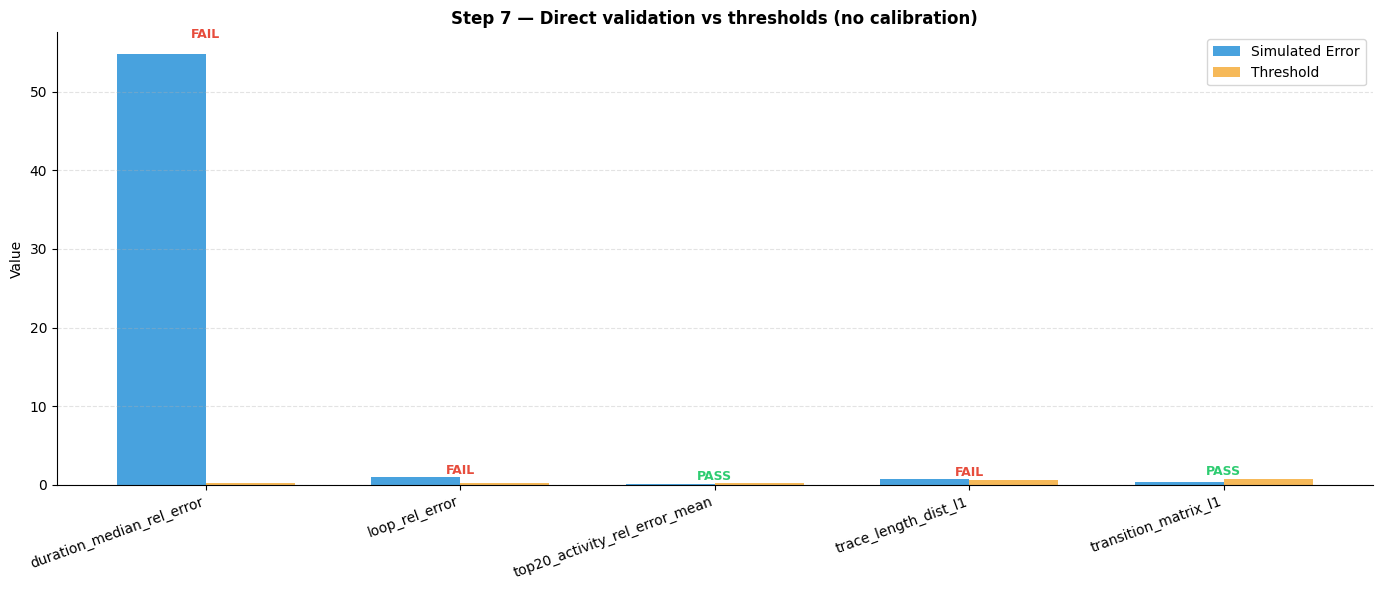

Saved chart: /home/praharsha/Desktop/bueracratic-workflow-analyzer/output/sim_validation_chart.png


In [ ]:
plot_df = show_df[['metric', 'error_mean', 'threshold']].copy().sort_values('metric').reset_index(drop=True)
x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width / 2, plot_df['error_mean'], width=width, label='Simulated Error', color='#3498db', alpha=0.9)
ax.bar(x + width / 2, plot_df['threshold'], width=width, label='Threshold', color='#f39c12', alpha=0.7)

for i, row in plot_df.iterrows():
    is_pass = float(row['error_mean']) < float(row['threshold'])
    marker = 'PASS' if is_pass else 'FAIL'
    color = '#2ecc71' if is_pass else '#e74c3c'
    ax.text(i, max(float(row['error_mean']), float(row['threshold'])) * 1.03, marker, ha='center', va='bottom', fontsize=9, color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(plot_df['metric'], rotation=20, ha='right')
ax.set_ylabel('Value')
ax.set_title('Step 7 — Validation vs thresholds', fontweight='bold')
ax.grid(True, axis='y', linestyle='--', alpha=0.35)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(CHART_PATH, dpi=160, bbox_inches='tight')
plt.show()
print('Saved chart:', CHART_PATH.resolve())

## Step 7 complete

Generated artifacts:
- `output/sim_validation_metrics_by_run.csv`
- `output/sim_validation_report.csv`
- `output/sim_validation_chart.png`

Notes:
- Validation is computed from current simulation outputs against real data.
- Metrics are evaluated against thresholds with PASS/FAIL status.